# Лабораторная работа №2

#### Выполнили:
-  Косарев Илья, 466304
-  Капустина Юлия, 466110
-  Воложева Таисия, 489858



This notebook demonstrates 7 optimizers implemented:
- Simulated Annealing (SA)
- Genetic Algorithm (GA)
- GD with Momentum
- RMSProp
- Adam
- AdamW
- Lion

Experiments:
- Rosenbrock (2D and ND)
- Rastrigin (2D and ND)
- Levi N13 (2D)

Rosenbrock (ND):
$$
f(\mathbf{x}) = \sum_{i=1}^{n-1}\left[100\left(x_{i+1} - x_i^2\right)^2 + (1 - x_i)^2\right],\quad f(1,\ldots,1)=0
$$

Rastrigin (ND):
$$
f(\mathbf{x}) = A n + \sum_{i=1}^{n}\left[x_i^2 - A\cos(2\pi x_i)\right],\quad A=10,\quad f(0,\ldots,0)=0
$$

Levi N13 (2D):
$$
f(x,y) = \sin^2(3\pi x) + (x-1)^2\left(1+\sin^2(3\pi y)\right) + (y-1)^2\left(1+\sin^2(2\pi y)\right),\quad f(1,1)=0
$$

Notation:
- $x_t$ is the current parameter vector
- $g_t = \nabla f(x_t)$ is the gradient
- $\alpha$ is the learning rate
- $\epsilon$ prevents division by zero

Momentum:
$$
m_t = \beta m_{t-1} + (1-\beta)g_t,\qquad x_{t+1}=x_t-\alpha m_t
$$

RMSProp:
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2,\qquad x_{t+1}=x_t-\frac{\alpha}{\sqrt{v_t}+\epsilon}g_t
$$

Adam:
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$
$$
\hat m_t = \frac{m_t}{1-\beta_1^t},\qquad \hat v_t = \frac{v_t}{1-\beta_2^t},\qquad x_{t+1}=x_t-\alpha\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

AdamW:
$$
x_{t+1}=x_t-\alpha\left(\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}+\lambda x_t\right)
$$

Lion:
$$
c_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$
$$
x_{t+1}=x_t-\alpha\,\mathrm{sign}(c_t)-\alpha\lambda x_t,\qquad m_t = \beta_2 m_{t-1} + (1-\beta_2)g_t
$$

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from objectives import get_objective
from optimizers import ALL_OPTIMIZERS
from runner import run_optimization
from utils import make_rng, make_uniform_point, make_uniform_population

plt.rcParams['figure.figsize'] = (8, 4)
pd.set_option('display.max_rows', 300)

LOG_DIR = Path('.')

# Select methods to benchmark by editing this dictionary.
METHODS = {
    'sa': ALL_OPTIMIZERS['sa'],
    'ga': ALL_OPTIMIZERS['ga'],
    'gd_momentum': ALL_OPTIMIZERS['gd_momentum'],
    'rmsprop': ALL_OPTIMIZERS['rmsprop'],
    'adam': ALL_OPTIMIZERS['adam'],
    'adamw': ALL_OPTIMIZERS['adamw'],
    'lion': ALL_OPTIMIZERS['lion'],
}

In [3]:
def build_kwargs(algorithm_name: str, spec, seed: int) -> dict:
    rng = make_rng(seed)

    if algorithm_name == 'sa':
        return {
            'f': spec.func,
            'x0': make_uniform_point(rng, spec.dim, spec.bounds),
            'bounds': spec.bounds,
            'max_iter': 500,
            'init_temp': 6.0,
            'cooling': 0.99,
            'step_scale': 0.2,
            'boundary': 'reflect',
            'seed': seed,
        }

    if algorithm_name == 'ga':
        return {
            'f': spec.func,
            'x0_population': make_uniform_population(rng, 36, spec.dim, spec.bounds),
            'bounds': spec.bounds,
            'max_iter': 150,
            'population_size': 36,
            'elite_size': 4,
            'mutation_sigma': 0.12,
            'boundary': 'reflect',
            'seed': seed,
        }

    common = {
        'f': spec.func,
        'grad': spec.grad,
        'x0': make_uniform_point(rng, spec.dim, spec.bounds),
        'bounds': spec.bounds,
        'max_iter': 2000,
        'tol_grad': 1e-8,
        'boundary': 'clip',
    }

    if algorithm_name == 'gd_momentum':
        common.update({'lr': 0.1, 'beta': 0.9})
    elif algorithm_name == 'rmsprop':
        common.update({'lr': 0.1, 'beta2': 0.9, 'eps': 1e-8})
    elif algorithm_name == 'adam':
        common.update({'lr': 0.1, 'beta1': 0.9, 'beta2': 0.9, 'eps': 1e-8})
    elif algorithm_name == 'adamw':
        common.update({'lr': 0.1, 'beta1': 0.9, 'beta2': 0.9, 'eps': 1e-8, 'weight_decay': 1e-3})
    elif algorithm_name == 'lion':
        common.update({'lr': 0.1, 'beta1': 0.9, 'beta2': 0.9, 'weight_decay': 5e-4})

    return common


def run_experiment_suite(
    tasks: list[tuple[str, int]],
    methods: dict[str, object] | None = None,
) -> pd.DataFrame:
    selected_methods = METHODS if methods is None else methods

    records = []
    for objective_name, dim in tasks:
        spec = get_objective(objective_name, dim=dim)
        function_key = f'{spec.name}_{dim}d'

        for idx, (method_name, algorithm) in enumerate(selected_methods.items()):
            kwargs = build_kwargs(method_name, spec, seed=1000 + 20 * idx + dim)
            _, f_best, meta = run_optimization(
                algorithm=algorithm,
                algo_kwargs=kwargs,
                max_restarts=1,
                log_dir=LOG_DIR,
                algorithm_name=method_name,
                function_name=function_key,
                dim=dim,
            )
            records.append(
                {
                    'objective': spec.name,
                    'dim': dim,
                    'algorithm': method_name,
                    'f_best': f_best,
                    'iterations': int(meta.get('iterations', 0)),
                    'reason': str(meta.get('reason', 'n/a')),
                    'function_key': function_key,
                }
            )

    frame = pd.DataFrame(records)
    return frame.sort_values(['objective', 'dim', 'f_best']).reset_index(drop=True)

In [4]:
tasks = [
    ('rosenbrock', 2),
    ('rosenbrock', 10),
    ('rastrigin', 2),
    ('rastrigin', 10),
    ('levi_n13', 2),
]

summary = run_experiment_suite(tasks)
summary

,objective,dim,algorithm,f_best,iterations,reason,function_key
0,levi_n13,2,ga,0.000113,150,max_iter,levi_n13_2d
1,levi_n13,2,lion,0.014639,2000,max_iter,levi_n13_2d
2,levi_n13,2,gd_momentum,0.214204,288,tol_f,levi_n13_2d
3,levi_n13,2,adam,24.884734,2000,max_iter,levi_n13_2d
4,levi_n13,2,sa,30.878015,106,tol_f,levi_n13_2d
5,levi_n13,2,rmsprop,53.896187,2000,max_iter,levi_n13_2d
6,levi_n13,2,adamw,99.974852,2000,max_iter,levi_n13_2d
7,rastrigin,2,ga,0.996520,150,max_iter,rastrigin_2d
8,rastrigin,2,adam,7.959678,2000,max_iter,rastrigin_2d
9,rastrigin,2,sa,9.957963,292,tol_f,rastrigin_2d


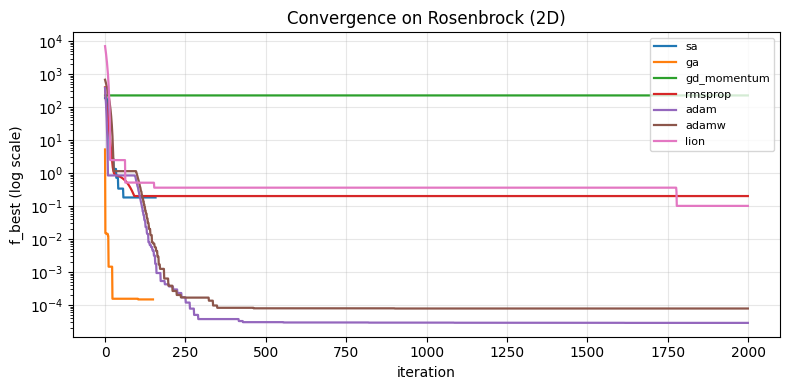

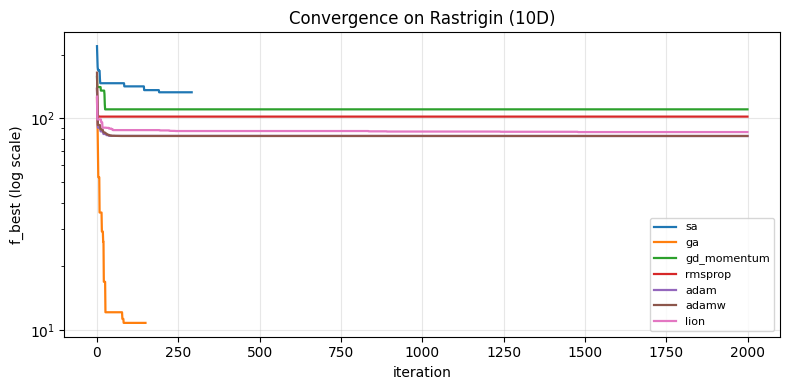

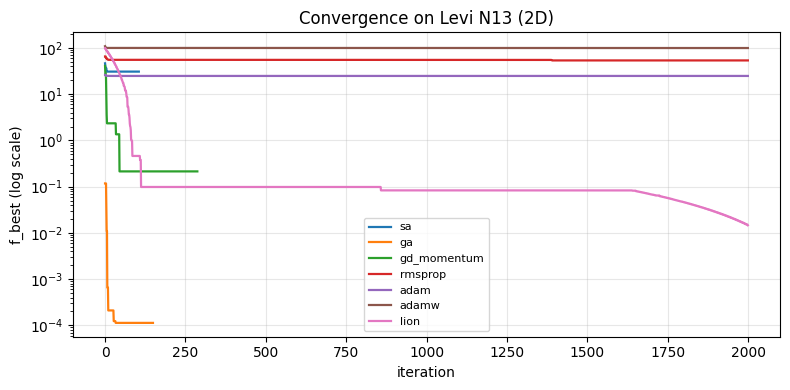

In [5]:
def read_log(algorithm: str, function_key: str) -> pd.DataFrame:
    path = LOG_DIR / f'{algorithm}_{function_key}_log_attempt1.csv'
    return pd.read_csv(path)


def plot_convergence(
    function_key: str,
    title: str,
    methods: dict[str, object] | None = None,
) -> None:
    selected_methods = METHODS if methods is None else methods

    plt.figure(figsize=(8, 4))
    for method_name in selected_methods:
        df = read_log(method_name, function_key)
        plt.plot(df['iteration'], df['f_best'], label=method_name, linewidth=1.6)

    plt.yscale('log')
    plt.xlabel('iteration')
    plt.ylabel('f_best (log scale)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_convergence('rosenbrock_2d', 'Convergence on Rosenbrock (2D)')
plot_convergence('rastrigin_10d', 'Convergence on Rastrigin (10D)')
plot_convergence('levi_n13_2d', 'Convergence on Levi N13 (2D)')

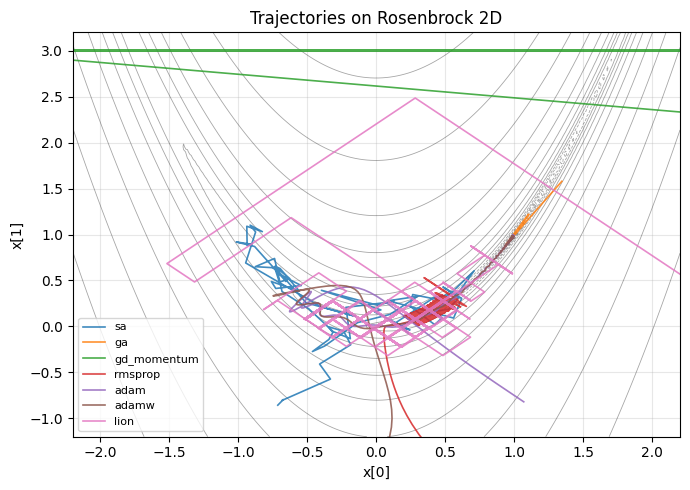

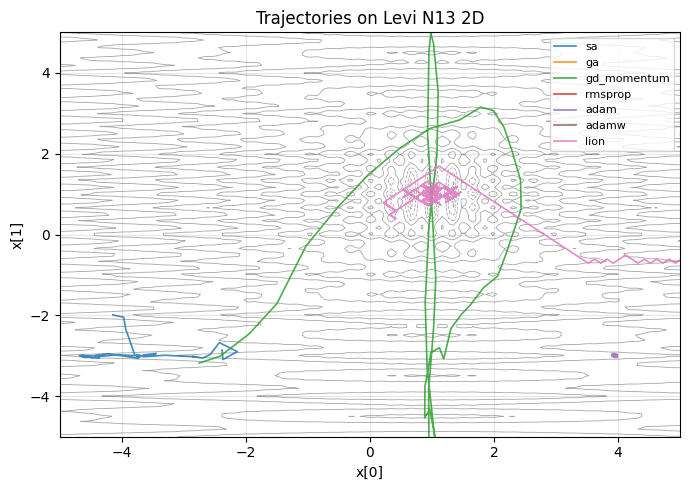

,objective,dim,algorithm,f_best,iterations,reason
0,levi_n13,2,ga,0.000113,150,max_iter
1,levi_n13,2,lion,0.014639,2000,max_iter
2,levi_n13,2,gd_momentum,0.214204,288,tol_f
3,levi_n13,2,adam,24.884734,2000,max_iter
4,levi_n13,2,sa,30.878015,106,tol_f
5,levi_n13,2,rmsprop,53.896187,2000,max_iter
6,levi_n13,2,adamw,99.974852,2000,max_iter
7,rastrigin,2,ga,0.996520,150,max_iter
8,rastrigin,2,adam,7.959678,2000,max_iter
9,rastrigin,2,sa,9.957963,292,tol_f


In [6]:
def plot_trajectory_2d(
    function_key: str,
    title: str,
    xlim=None,
    ylim=None,
    methods: dict[str, object] | None = None,
    contour_levels: int = 18,
) -> None:
    selected_methods = METHODS if methods is None else methods

    objective_name, dim_part = function_key.rsplit('_', 1)
    dim = int(dim_part.rstrip('d'))
    spec = get_objective(objective_name, dim=dim)

    if xlim is None:
        xlim = (spec.bounds[0], spec.bounds[1])
    if ylim is None:
        ylim = (spec.bounds[0], spec.bounds[1])

    x_grid = np.linspace(xlim[0], xlim[1], 160)
    y_grid = np.linspace(ylim[0], ylim[1], 160)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid = np.stack([X.ravel(), Y.ravel()], axis=1)
    Z = np.array([spec.func(point) for point in grid], dtype=float).reshape(X.shape)
    Z_log = np.log10(Z + 1e-9)
    levels = np.linspace(float(Z_log.min()), float(Z_log.max()), contour_levels)

    plt.figure(figsize=(7, 5))
    plt.contour(X, Y, Z_log, levels=levels, colors='black', linewidths=0.6, alpha=0.35)

    for method_name in selected_methods:
        df = read_log(method_name, function_key)
        points = np.vstack(df['x_current'].map(json.loads).to_numpy())
        if points.shape[1] != 2:
            continue
        plt.plot(points[:, 0], points[:, 1], linewidth=1.2, alpha=0.85, label=method_name)

    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel('x[0]')
    plt.ylabel('x[1]')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_trajectory_2d('rosenbrock_2d', 'Trajectories on Rosenbrock 2D', xlim=(-2.2, 2.2), ylim=(-1.2, 3.2))
plot_trajectory_2d('levi_n13_2d', 'Trajectories on Levi N13 2D', xlim=(-5.0, 5.0), ylim=(-5.0, 5.0))

summary[['objective', 'dim', 'algorithm', 'f_best', 'iterations', 'reason']].sort_values(
    ['objective', 'dim', 'f_best']
)

## Анализ сходимости в зависимости от начального расстояния

Запускаем все алгоритмы с трёх типов стартовых позиций:
- **close** (~0.5 от оптимума)
- **medium** (~2.5) 
- **far** (~4.5)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from objectives import get_objective
from utils import make_rng, make_point_at_distance
from main import _build_kwargs

ZONES = {"close": 0.5, "medium": 2.5, "far": 4.5}
TASK = ("rosenbrock", 2)

function_name, dim = TASK
spec = get_objective(function_name, dim=dim)

all_histories = []

for zone_name, dist in ZONES.items():
    rng = make_rng(42)
    x0_zone = make_point_at_distance(rng, spec.optimum_point, dist, spec.bounds)

    for idx, (algo_name, algo) in enumerate(ALL_OPTIMIZERS.items()):
        kwargs = _build_kwargs(algo_name, spec, seed=100 + idx)

        if algo_name == "ga":
            rng2 = make_rng(200 + idx)
            pop = [x0_zone + rng2.normal(0, 0.3, size=spec.dim)
                   for _ in range(32)]
            kwargs["x0_population"] = pop
        else:
            kwargs["x0"] = x0_zone.copy()

        kwargs.pop("logger", None)

        history = []
        original_f = kwargs["f"]

        def make_tracked_f(orig_f, hist, opt_x):
            call_counter = [0]
            def tracked(x):
                val = orig_f(x)
                hist.append({
                    "call": call_counter[0],
                    "dist_to_opt": float(np.linalg.norm(x - opt_x)),
                    "f_current": val,
                })
                call_counter[0] += 1
                return val
            return tracked

        kwargs["f"] = make_tracked_f(original_f, history, spec.optimum_point)

        try:
            x_best, f_best, meta = algo(**kwargs)
            for h in history:
                h.update({"algo": algo_name, "zone": zone_name,
                          "dist_init": dist})
            all_histories.extend(history)
        except Exception as e:
            print(f"  Ошибка {algo_name} / zone={zone_name}: {e}")

df_hist = pd.DataFrame(all_histories)
print(f"Собрано {len(df_hist)} записей для {df_hist['algo'].nunique()} алгоритмов")

Собрано 22737 записей для 7 алгоритмов


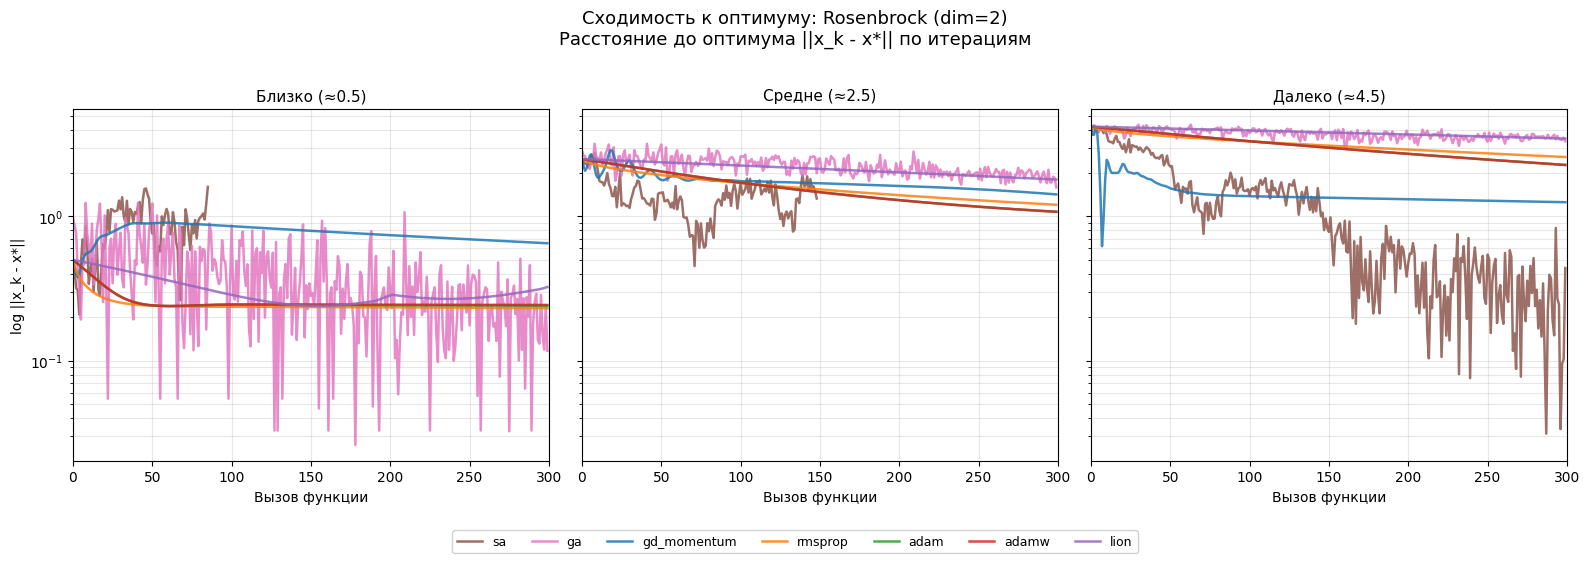

In [8]:
ZONE_LABELS = {"close": "Близко (≈0.5)",
               "medium": "Средне (≈2.5)",
               "far": "Далеко (≈4.5)"}
COLORS = {
    "gd_momentum": "#1f77b4",
    "rmsprop":     "#ff7f0e",
    "adam":        "#2ca02c",
    "adamw":       "#d62728",
    "lion":        "#9467bd",
    "sa":          "#8c564b",
    "ga":          "#e377c2",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    f"Сходимость к оптимуму: {function_name.capitalize()} "
    f"(dim={dim})\nРасстояние до оптимума ||x_k - x*|| по итерациям",
    fontsize=13, y=1.02
)

for ax, zone_name in zip(axes, ZONES.keys()):
    df_zone = df_hist[df_hist["zone"] == zone_name]

    for algo_name in ALL_OPTIMIZERS:
        df_algo = df_zone[df_zone["algo"] == algo_name].reset_index(drop=True)
        if df_algo.empty:
            continue

        df_algo = df_algo.head(300)

        ax.semilogy(
            df_algo.index,
            df_algo["dist_to_opt"].clip(lower=1e-10),
            label=algo_name,
            color=COLORS.get(algo_name, "gray"),
            linewidth=1.8,
            alpha=0.85,
        )

    ax.set_title(ZONE_LABELS[zone_name], fontsize=11)
    ax.set_xlabel("Вызов функции")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlim(0, 300)

axes[0].set_ylabel("log ||x_k - x*||")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7,
           bbox_to_anchor=(0.5, -0.08), fontsize=9,
           framealpha=0.9)

plt.tight_layout()
plt.show()

In [9]:
summary = (
    df_hist.groupby(["algo", "zone"])["f_current"]
    .min()
    .rename("f_best_achieved")
    .reset_index()
    .pivot(index="algo", columns="zone", values="f_best_achieved")
    [list(ZONES.keys())]
    .round(4)
)

print(f"\n=== Лучшее f_best по зонам ({function_name}, dim={dim}) ===")
print(summary.to_string())


=== Лучшее f_best по зонам (rosenbrock, dim=2) ===
zone          close  medium       far
algo                                 
adam         0.0113  0.2391   23.9882
adamw        0.0120  0.2404   23.6418
ga           0.0000  0.0002    0.0002
gd_momentum  0.0406  0.1381    0.1564
lion         0.0139  1.2969  550.0427
rmsprop      0.0072  0.2810   42.8278
sa           0.1444  0.1734    0.0039


In [10]:
N_EXPERIMENTS = 15

records = []

for zone_name, dist in ZONES.items():
    for exp_idx in range(N_EXPERIMENTS):
        rng = make_rng(exp_idx * 1000)
        x0_zone = make_point_at_distance(
            rng, spec.optimum_point, dist, spec.bounds
        )

        for algo_idx, (algo_name, algo) in enumerate(ALL_OPTIMIZERS.items()):
            kwargs = _build_kwargs(algo_name, spec, seed=exp_idx * 100 + algo_idx)

            if algo_name == "ga":
                rng2 = make_rng(exp_idx * 500 + algo_idx)
                kwargs["x0_population"] = [
                    x0_zone + rng2.normal(0, 0.3, size=spec.dim)
                    for _ in range(32)
                ]
            else:
                kwargs["x0"] = x0_zone.copy()

            kwargs.pop("logger", None)

            try:
                x_best, f_best, meta = algo(**kwargs)
                dist_final = float(np.linalg.norm(x_best - spec.optimum_point))
                records.append({
                    "zone":         zone_name,
                    "init_dist":    dist,
                    "algo":         algo_name,
                    "exp":          exp_idx,
                    "f_best":       f_best,
                    "dist_final":   dist_final,
                    "iters":        int(meta.get("iterations", 0)),
                    "converged":    dist_final < 0.01,
                })
            except Exception as e:
                print(f"[skip] {algo_name} zone={zone_name} exp={exp_idx}: {e}")

df_multi = pd.DataFrame(records)

summary_multi = (
    df_multi
    .groupby(["algo", "zone"])
    .agg(
        f_best_mean   =("f_best",     "mean"),
        f_best_std    =("f_best",     "std"),
        dist_final_mean=("dist_final","mean"),
        dist_final_std =("dist_final","std"),
        iters_mean    =("iters",      "mean"),
        conv_rate     =("converged",  "mean"),
    )
    .round(4)
    .reset_index()
)

zone_order = list(ZONES.keys())
summary_multi["zone"] = pd.Categorical(
    summary_multi["zone"], categories=zone_order, ordered=True
)
summary_multi = summary_multi.sort_values(["algo", "zone"])

print(f"Всего запусков: {len(df_multi)}  "
      f"({N_EXPERIMENTS} экспериментов × {len(ZONES)} зоны × "
      f"{len(ALL_OPTIMIZERS)} алгоритмов)\n")
print(summary_multi.to_string(index=False))

Всего запусков: 315  (15 экспериментов × 3 зоны × 7 алгоритмов)

       algo   zone  f_best_mean  f_best_std  dist_final_mean  dist_final_std  iters_mean  conv_rate
       adam  close       0.0129      0.0130           0.2073          0.1518    670.1333     0.1333
       adam medium       1.8429      2.1666           1.5840          0.7543    700.0000     0.0000
       adam    far      10.8899     17.3892           2.0189          0.9034    700.0000     0.0000
      adamw  close       0.0129      0.0129           0.2069          0.1504    700.0000     0.1333
      adamw medium       1.8324      2.1594           1.5782          0.7509    700.0000     0.0000
      adamw    far      10.7462     17.1089           2.0125          0.8987    700.0000     0.0000
         ga  close       0.0001      0.0002           0.0145          0.0144    120.0000     0.5333
         ga medium       0.0002      0.0002           0.0149          0.0083    120.0000     0.3333
         ga    far       0.0012    

**GA** показывает наилучшее качество решения во всех зонах и наименьшую
зависимость от удалённости старта — популяционный поиск эффективно
компенсирует расстояние до оптимума.

**Градиентные методы (Adam, AdamW, RMSProp, GD+momentum)** резко деградируют
при переходе от близких стартов к дальним: бюджет итераций исчерпывается
без сходимости. Вблизи оптимума они показывают относительную устойчивость, но на удалении становятся ненадёжны.

**Lion** нестабилен: при далёких стартах разброс результатов слишком высок (при близком старте конкурентоспособен, но непредсказуем при удалении).

**SA** деградирует медленнее градиентных методов, но уступает GA по точности финального решения.

**Вывод**: методы нулевого порядка (GA, SA) значительно устойчивее к выбору начальной точки, чем методы первого порядка. Градиентные методы выигрывают только при условии хорошей инициализации.

Градиентные методы сильно страдают из-за топологии функции Розенброка - она представляет собой узкую изогнутую долину с очень крутыми склонами. При удалённом старте вектор градиента направлен не к глобальному минимуму, а на ближайший склон долины. В результате алгоритмы попадают в ловушку: они совершают зигзагообразные колебания поперёк склона, почти не продвигаясь вдоль самой долины к цели, тогда как методы нулевого порядка игнорируют эту локальную кривизну за счёт широкого случайного поиска.

### Оптимизация функции (с приколом)

$$
c_1 = \mathrm{round}(\sin(10 x_2)) + 2,\quad
c_2 = \mathrm{round}(\sin(7 x_1)) + 2
$$

$$
f(x_1, x_2) = d \left( [(x_1 c_1)^2 + x_2 - 10]^2 + [x_1 + (x_2 c_2)^2 - 7]^2 \right),\quad d=0.18
$$

Для градиентов считаем производные от `round(...)` равными 0 (локальная аппроксимация), чтобы хоть как-то применить градиентные методы.

Start point: [ 2.18822236 -5.35414777]


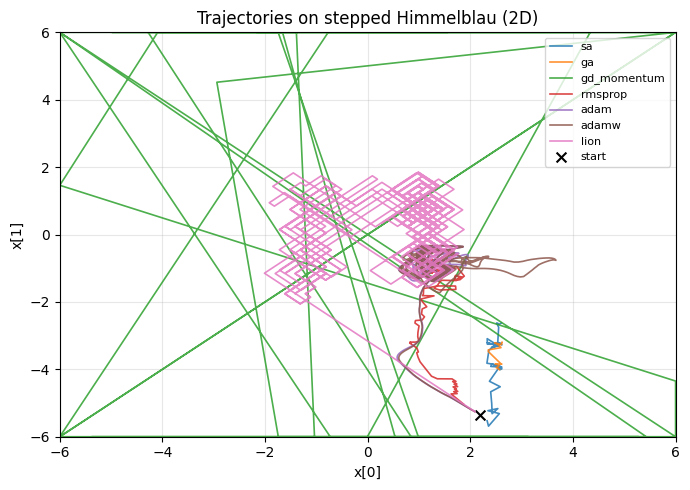


Найденные локальные минимумы (по каждому методу):
  algorithm     f_best            x_best  iterations   reason
       lion   0.033472   [0.9978 0.8424]        2000 max_iter
      adamw   0.229988 [ 1.7242 -1.2453]        2000 max_iter
    rmsprop   0.252498 [ 1.7354 -1.2379]        2000 max_iter
       adam   1.417697 [ 1.7914 -0.8923]        2000 max_iter
         sa   7.266633 [ 2.605  -2.6263]         500 max_iter
         ga  13.405085 [ 2.6174 -3.1983]         150 max_iter
gd_momentum 139.566279 [-1.2309  6.    ]          41 tol_step


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from objectives import ObjectiveSpec, stepped_himmelblau_2d, stepped_himmelblau_grad_2d

HIMMEL_BOUNDS = (-6.0, 6.0)
spec_h = ObjectiveSpec(
    name="stepped_himmelblau",
    dim=2,
    func=stepped_himmelblau_2d,
    grad=stepped_himmelblau_grad_2d,
    optimum_point=np.zeros(2, dtype=float),
    optimum_value=float("nan"),
    bounds=HIMMEL_BOUNDS,
)
function_key = "stepped_himmelblau_2d"

rng0 = make_rng(123)
x0_base = make_uniform_point(rng0, spec_h.dim, spec_h.bounds)
print(f"Start point: {x0_base}")

results_h = []

for idx, (algo_name, algo) in enumerate(ALL_OPTIMIZERS.items()):
    kwargs = build_kwargs(algo_name, spec_h, seed=500 + idx)

    if algo_name == "ga":
        rng2 = make_rng(800 + idx)
        population_size = int(kwargs.get("population_size", 36))
        lower, upper = spec_h.bounds
        kwargs["x0_population"] = [
            np.clip(x0_base + rng2.normal(0, 0.6, size=spec_h.dim), lower, upper)
            for _ in range(population_size)
        ]
    else:
        kwargs["x0"] = x0_base.copy()

    try:
        x_best, f_best, meta = run_optimization(
            algorithm=algo,
            algo_kwargs=kwargs,
            max_restarts=1,
            log_dir=LOG_DIR,
            algorithm_name=algo_name,
            function_name=function_key,
            dim=spec_h.dim,
        )
    except Exception as exc:
        print(f"[skip] {algo_name}: {exc}")
        continue

    results_h.append(
        {
            "algorithm": algo_name,
            "f_best": f_best,
            "x_best": x_best,
            "iterations": int(meta.get("iterations", 0)),
            "reason": str(meta.get("reason", "n/a")),
        }
    )

plt.figure(figsize=(7, 5))
for algo_name in ALL_OPTIMIZERS:
    try:
        df = read_log(algo_name, function_key)
    except FileNotFoundError:
        continue
    points = np.vstack(df["x_current"].map(json.loads).to_numpy())
    if points.shape[1] != 2:
        continue
    plt.plot(points[:, 0], points[:, 1], linewidth=1.2, alpha=0.85, label=algo_name)

plt.scatter([x0_base[0]], [x0_base[1]], marker="x", s=50, color="black", label="start")
plt.xlim(*spec_h.bounds)
plt.ylim(*spec_h.bounds)
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.title("Trajectories on stepped Himmelblau (2D)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

if results_h:
    df_minima = pd.DataFrame(results_h)
    df_minima["x_best"] = df_minima["x_best"].apply(
        lambda x: np.array2string(np.asarray(x), precision=4, suppress_small=True)
    )
    df_minima = df_minima.sort_values("f_best").reset_index(drop=True)
else:
    df_minima = pd.DataFrame(
        columns=["algorithm", "f_best", "x_best", "iterations", "reason"]
    )

print("\nНайденные локальные минимумы (по каждому методу):")
print(df_minima.to_string(index=False))

## Выводы по модифицированной функции

- В этом запуске **лучший результат дал Lion** (минимальный `f_best`), за ним идут **AdamW** и **RMSProp**; классический **GD+momentum** сильно отстал.
- **SA** и **GA** здесь оказались хуже по `f_best`, что говорит о сильной зависимости от стартовой точки и параметров (для разрывной цели это нормально).
- Негладкость из-за `round(...)` делает поведение **градиентных методов нестабильным и чувствительным** к локальным плато: иногда они выигрывают, иногда застревают.
- **Нулевого порядка** остаются полезными для поиска разных локальных минимумов, но по качеству в этом конкретном прогоне уступили.
- **Итог**: для данной особой функции нет универсального победителя - стоит сравнивать на нескольких запусках и считать устойчивость, а не только одно значение `f_best`.